# 子图持久化策略

就是当父图配置好检查点后，可以在子图添加checkpointer的参数，让他执行三种策略
1. per-invocation， invocation记忆祈祷，检查点和中断可以保存下来，但是没有多轮记忆，checkpointer=None或者不写，注意这个不是父图的 ，是基于父图有检查点，， 子图有记忆，但是不能多轮， 同thread_id只能用一次
2. per-thread，  子图有记忆， thread_id一直记得
3. stateless， 不开启检查点， 子图不能保存也不能中断

2026-09-19 14:22:51.049 | INFO     | __main__:subgraph_strip_node:15 - 子图 subgraph_strip_node 节点执行了
2026-09-19 14:22:51.050 | INFO     | __main__:subgraph_punctuate_node:24 - 子图 subgraph_punctuate_node 节点执行了


============================== ->   中断信息   <- ==============================
{'raw_text': '   LangGraph 真有意思        ', '__interrupt__': [Interrupt(value='您希望在句尾添加的标点符号是？[。/，/！/？/；]', id='87d2bb55fbc3dee8fc4da23508acd9f4')]}


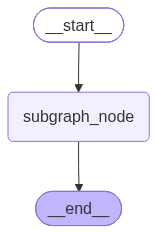

In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

from loguru import logger

# 定义全局共享状态
class OverAllState(TypedDict):
    raw_text: str # 未清洗文本
    cleaned_text: str # 清洗后的文本

# 构建子图
def subgraph_strip_node(state: OverAllState) -> OverAllState:
    logger.info("子图 subgraph_strip_node 节点执行了")
    raw_text = state["raw_text"]
    stripped_text = raw_text.strip()

    return {
        "cleaned_text": stripped_text
    }

def subgraph_punctuate_node(state: OverAllState) -> OverAllState:
    logger.info("子图 subgraph_punctuate_node 节点执行了")
    cleaned_text = state["cleaned_text"]
    punctuation = interrupt("您希望在句尾添加的标点符号是？[。/，/！/？/；]")
    punctuation1 = interrupt("您希望在句尾添加的标点符号是？[。/，/！/？/；]") # 有bug，不写两个，不能测试stateless（因为一个中断是父图有检查点，两个的话依赖子图恢复中断的能力）
    punctuated_text = cleaned_text + punctuation + punctuation1

    return {
        "cleaned_text": punctuated_text
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("subgraph_strip_node", subgraph_strip_node)
builder.add_node("subgraph_punctuate_node", subgraph_punctuate_node)

builder.add_edge(START, "subgraph_strip_node")
builder.add_edge("subgraph_strip_node", "subgraph_punctuate_node")
builder.add_edge("subgraph_punctuate_node", END)

# ==================================================
# 【策略切换点】只需修改这一行
# subgraph = builder.compile()  # Per-invocation（默认）
# subgraph = builder.compile(checkpointer=True)   # Per-thread
subgraph = builder.compile(checkpointer=False)  # Stateless（中断不可用） 没有检查点的话，会报错
# ==================================================

# 构建父图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("subgraph_node", subgraph)

builder.add_edge(START, "subgraph_node")
builder.add_edge("subgraph_node", END)

checkpointer = InMemorySaver()
parent_graph = builder.compile(checkpointer=checkpointer)

raw_text = "   LangGraph 真有意思        "
config = {"configurable": {"thread_id": "123"}}
# 首次调用
interrupted_res = parent_graph.invoke(
    {"raw_text": raw_text},
    config=config
)
print("=" * 30, "->   中断信息   <-", "=" * 30)
print(interrupted_res)


from IPython.display import display, Image
display(
    Image(
        parent_graph
        .get_graph(xray=True)
        .draw_mermaid_png()
    )
)


In [ ]:

# 恢复调用
parent_graph.invoke(
    Command(resume="！"),
    config=config
)
res = parent_graph.invoke(  # 报错原因，没办法恢复第二个，卡死在恢复一次的位置
    Command(resume="！"),
    config=config
)

cleaned_text = res["cleaned_text"]
print("=" * 30, "->   原始文本   <-", "=" * 30)
print(raw_text)
print("=" * 30, "-> 清洗后的文本 <-", "=" * 30)
print(cleaned_text)

2026-09-19 14:22:53.152 | INFO     | __main__:subgraph_strip_node:15 - 子图 subgraph_strip_node 节点执行了
2026-09-19 14:22:53.153 | INFO     | __main__:subgraph_punctuate_node:24 - 子图 subgraph_punctuate_node 节点执行了
2026-09-19 14:22:53.165 | INFO     | __main__:subgraph_strip_node:15 - 子图 subgraph_strip_node 节点执行了
2026-09-19 14:22:53.166 | INFO     | __main__:subgraph_punctuate_node:24 - 子图 subgraph_punctuate_node 节点执行了


KeyError: 'cleaned_text'